# Adult Census — MLflow Tracking + Model Selection (OOF CV) + Model Registry

This notebook walks through a clean end-to-end MLflow workflow on the Adult Census dataset:

- Track experiments with MLflow (SQLite backend + local artifact store)
- Build multiple baseline models (LogReg / HGB / RF / XGBoost)
- Evaluate models with consistent 5-fold Stratified CV
- Compute and compare **OOF ROC + PR curves** (reliable selection under class imbalance)
- Select a **champion model** using **CV PR-AUC**
- Register the champion into the **MLflow Model Registry** and prepare staging/production lifecycle

Focus: reproducibility, fair model comparison, and MLflow best practices for tracking + registry.

## MLflow Tracking Setup (Local SQLite + Artifact Store)

In [1]:
import sys
from pathlib import Path
import mlflow
import numpy as np
import pandas as pd

sys.executable

# Repo root (notebook is in /notebooks)
PROJECT_ROOT = Path.cwd().parent

# Dataset path
csv_path = PROJECT_ROOT / "data" / "raw" / "adult-census.csv"

# Everything under repo/mlflow/
MLFLOW_DIR = PROJECT_ROOT / "mlflow"
MLFLOW_DIR.mkdir(parents=True, exist_ok=True)

MLFLOW_DB = (MLFLOW_DIR / "mlflow.db").resolve()
ARTIFACT_ROOT = (MLFLOW_DIR / "artifacts").resolve()
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)

mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_DB.as_posix()}")

EXPERIMENT_NAME = "adult_census_tracking"
exp = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
if exp is None:
    mlflow.create_experiment(
        name=EXPERIMENT_NAME,
        artifact_location=ARTIFACT_ROOT.as_uri(),
    )
mlflow.set_experiment(EXPERIMENT_NAME)

# Reports outputs (local, then logged to MLflow as artifacts)
REPORTS_DIR = PROJECT_ROOT / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT  =", PROJECT_ROOT)
print("csv_path      =", csv_path)
print("exists?       =", csv_path.exists())
print("MLFLOW_DIR    =", MLFLOW_DIR)
print("TRACKING_URI  =", mlflow.get_tracking_uri())
print("MLFLOW_DB     =", MLFLOW_DB)
print("ARTIFACT_ROOT =", ARTIFACT_ROOT)
print("REPORTS_DIR   =", REPORTS_DIR)

2026/01/21 15:42:12 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/01/21 15:42:12 INFO mlflow.store.db.utils: Updating database tables
2026/01/21 15:42:12 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/01/21 15:42:12 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2026/01/21 15:42:12 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/01/21 15:42:12 INFO alembic.runtime.migration: Will assume non-transactional DDL.


PROJECT_ROOT  = h:\Documents\2. Perso\github\mlflow
csv_path      = h:\Documents\2. Perso\github\mlflow\data\raw\adult-census.csv
exists?       = True
MLFLOW_DIR    = h:\Documents\2. Perso\github\mlflow\mlflow
TRACKING_URI  = sqlite:///H:/Documents/2. Perso/github/mlflow/mlflow/mlflow.db
MLFLOW_DB     = H:\Documents\2. Perso\github\mlflow\mlflow\mlflow.db
ARTIFACT_ROOT = H:\Documents\2. Perso\github\mlflow\mlflow\artifacts
REPORTS_DIR   = h:\Documents\2. Perso\github\mlflow\reports


## Data Loading + Split + CV Setup (Target Encoding + OOF Storage)

In [2]:
adult_census = pd.read_csv(csv_path)
adult_census = adult_census.drop(columns="education.num")

target_name = "income"
target = adult_census[target_name]
data = adult_census.drop(columns=[target_name])

In [3]:
from sklearn.compose import make_column_selector as selector

numerical_columns_selector = selector(dtype_exclude=object)
categorical_columns_selector = selector(dtype_include=object)

numerical_columns = numerical_columns_selector(data)
categorical_columns = categorical_columns_selector(data)

In [4]:
from sklearn.model_selection import train_test_split

# 1) Encode target with the exact mapping you want
target_map = {"<=50K": 0, ">50K": 1}

# if target is a pandas Series of strings
target_enc = target.map(target_map).astype("int64")

# (optional) safety check
# assert target_enc.isna().sum() == 0, f"Unmapped labels: {target[target_enc.isna()].unique()}"

# 2) Train/test split
data_train, data_test, target_train, target_test = train_test_split(
    data, target_enc, test_size=0.2, random_state=42, stratify=target_enc
)

In [5]:
# Encoded target distribution (0/1)
# --------------------------------------------

print("\nTarget distribution (%):")
print((target_enc.value_counts(normalize=True).sort_index() * 100).round(2))


Target distribution (%):
income
0    75.92
1    24.08
Name: proportion, dtype: float64


## Evaluation metrics (binary, imbalanced target)

The target is moderately imbalanced (~76% class 0 vs ~24% class 1), so accuracy can be misleading.
We prioritize **ROC-AUC** and **PR-AUC (Average Precision)** to evaluate ranking quality, and **F1 / Recall** to monitor performance on the minority class.

In [6]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score
)

# Consistent folds everywhere
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Global store for OOF predictions
OOF = {}  # {model_key: {"y_true": ..., "y_score": ...}}

scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "f1": "f1",
    "recall": "recall",
}

## Model #1 — LogisticRegression

In [7]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import make_column_transformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

categorical_preprocessor = OneHotEncoder(handle_unknown="ignore")
numerical_preprocessor = StandardScaler()

preprocessor = make_column_transformer(
    (categorical_preprocessor, categorical_columns),
    (numerical_preprocessor, numerical_columns),
)

logreg_ohe_scaler = make_pipeline(preprocessor, LogisticRegression(max_iter=500))

In [8]:
%%time
# CV + MLflow logging (LogReg OHE + Scaler) — consistent folds + OOF preds stored
# ------------------------------------------------------------------------------
# - Uses the SAME CV splitter everywhere (shuffle=True, random_state=42)
# - Logs mean/std per metric to MLflow
# - Logs ONLY non-default hyperparams (clean UI)
# - Stores mean_logreg/std_logreg as PR-AUC CV mean/std for model selection
# - Stores OOF predicted probabilities + labels (oof_proba_logreg / oof_pred_logreg)

import numpy as np
import mlflow
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict

with mlflow.start_run(run_name="logreg_ohe_scaler_cv"):
    # 1) CV metrics (fold-wise)
    cv_results = cross_validate(
        logreg_ohe_scaler,
        data,
        target_enc,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
    )

    # Keep a named copy for later selection
    cv_results_logreg = cv_results

    # Model-selection score (PR-AUC mean/std)
    mean_logreg = float(np.mean(cv_results["test_pr_auc"]))
    std_logreg = float(np.std(cv_results["test_pr_auc"]))

    # 2) OOF predicted probabilities (positive class)
    oof_proba_logreg = cross_val_predict(
        logreg_ohe_scaler,
        data,
        target_enc,
        cv=cv,
        method="predict_proba",
        n_jobs=-1,
    )[:, 1]

    # Optional: OOF hard predictions with a 0.5 threshold
    oof_pred_logreg = (oof_proba_logreg >= 0.5).astype(int)

    # ------------------------------------------------------------------
    # Params (clean UI): log only what you explicitly changed vs defaults
    # ------------------------------------------------------------------
    mlflow.log_param("model_key", "logreg_ohe_scaler")
    mlflow.log_param("model_family", "LogisticRegression")
    mlflow.log_param("cv_folds", cv.get_n_splits())
    mlflow.log_param("cv_shuffle", True)
    mlflow.log_param("cv_random_state", 42)

    # Non-defaults you set
    mlflow.log_param("ohe_handle_unknown", categorical_preprocessor.handle_unknown)  # "ignore"
    mlflow.log_param(
        "logreg_max_iter",
        logreg_ohe_scaler.named_steps["logisticregression"].max_iter,  # 500
    )

    # ------------------------------------------------------------------
    # Metrics: mean/std per metric
    # ------------------------------------------------------------------
    for m in scoring.keys():
        scores = cv_results[f"test_{m}"]
        mlflow.log_metric(f"cv_{m}_mean", float(np.mean(scores)))
        mlflow.log_metric(f"cv_{m}_std", float(np.std(scores)))

    print(
        "CV summary:\n"
        f"ROC-AUC : {np.mean(cv_results['test_roc_auc']):.4f} ± {np.std(cv_results['test_roc_auc']):.4f}\n"
        f"PR-AUC  : {mean_logreg:.4f} ± {std_logreg:.4f}\n"
        f"F1      : {np.mean(cv_results['test_f1']):.4f} ± {np.std(cv_results['test_f1']):.4f}\n"
        f"Recall  : {np.mean(cv_results['test_recall']):.4f} ± {np.std(cv_results['test_recall']):.4f}"
    )

print("Stored OOF preds -> oof_proba_logreg / oof_pred_logreg")

CV summary:
ROC-AUC : 0.9068 ± 0.0034
PR-AUC  : 0.7672 ± 0.0068
F1      : 0.6615 ± 0.0117
Recall  : 0.6008 ± 0.0139
Stored OOF preds -> oof_proba_logreg / oof_pred_logreg
CPU times: total: 2.17 s
Wall time: 12.3 s


## Model #2 — HistGradientBoosting

In [9]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline

categorical_preprocessor = OrdinalEncoder(
    handle_unknown="use_encoded_value", unknown_value=-1
)

preprocessor_hgb = make_column_transformer(
    (categorical_preprocessor, categorical_columns),
    remainder="passthrough",
)

hgb_ordinal = make_pipeline(preprocessor_hgb, HistGradientBoostingClassifier())

In [10]:
%%time
# CV + MLflow logging (HGB + OrdinalEncoder) — consistent folds + OOF preds stored
# ------------------------------------------------------------------------------
# - Uses the SAME CV splitter everywhere (shuffle=True, random_state=42)
# - Logs mean/std per metric to MLflow
# - Logs ONLY non-default hyperparams (clean UI)
# - Stores mean_hgb/std_hgb as PR-AUC CV mean/std for model selection
# - Stores OOF predicted probabilities + labels (oof_proba_hgb / oof_pred_hgb)

# Safety: avoid "run already active" issues
if mlflow.active_run() is not None:
    mlflow.end_run()

with mlflow.start_run(run_name="hgb_ordinal_cv"):
    # 1) CV metrics
    cv_results = cross_validate(
        hgb_ordinal,
        data,
        target_enc,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
    )

    cv_results_hgb = cv_results

    mean_hgb = float(np.mean(cv_results["test_pr_auc"]))
    std_hgb = float(np.std(cv_results["test_pr_auc"]))

    # 2) OOF predicted probabilities (positive class)
    oof_proba_hgb = cross_val_predict(
        hgb_ordinal,
        data,
        target_enc,
        cv=cv,
        method="predict_proba",
        n_jobs=-1,
    )[:, 1]

    # Optional: OOF hard predictions with 0.5 threshold
    oof_pred_hgb = (oof_proba_hgb >= 0.5).astype(int)

    # ------------------------------------------------------------------
    # Params (clean UI): log only what you explicitly changed vs defaults
    # ------------------------------------------------------------------
    mlflow.log_param("model_key", "hgb_ordinal")
    mlflow.log_param("model_family", "HistGradientBoostingClassifier")
    mlflow.log_param("cv_folds", cv.get_n_splits())
    mlflow.log_param("cv_shuffle", True)
    mlflow.log_param("cv_random_state", 42)

    # ✅ Non-defaults you set (log from the instantiated encoder, not fitted transformer)
    mlflow.log_param("ordinal_handle_unknown", categorical_preprocessor.handle_unknown)  # "use_encoded_value"
    mlflow.log_param("ordinal_unknown_value", categorical_preprocessor.unknown_value)    # -1

    # ------------------------------------------------------------------
    # Metrics: mean/std per metric
    # ------------------------------------------------------------------
    for m in scoring.keys():
        scores = cv_results[f"test_{m}"]
        mlflow.log_metric(f"cv_{m}_mean", float(np.mean(scores)))
        mlflow.log_metric(f"cv_{m}_std", float(np.std(scores)))

    print(
        "CV summary:\n"
        f"ROC-AUC : {np.mean(cv_results['test_roc_auc']):.4f} ± {np.std(cv_results['test_roc_auc']):.4f}\n"
        f"PR-AUC  : {mean_hgb:.4f} ± {std_hgb:.4f}\n"
        f"F1      : {np.mean(cv_results['test_f1']):.4f} ± {np.std(cv_results['test_f1']):.4f}\n"
        f"Recall  : {np.mean(cv_results['test_recall']):.4f} ± {np.std(cv_results['test_recall']):.4f}"
    )

print("Stored OOF preds -> oof_proba_hgb / oof_pred_hgb")

CV summary:
ROC-AUC : 0.9264 ± 0.0024
PR-AUC  : 0.8260 ± 0.0054
F1      : 0.7105 ± 0.0082
Recall  : 0.6489 ± 0.0088
Stored OOF preds -> oof_proba_hgb / oof_pred_hgb
CPU times: total: 1 s
Wall time: 10.1 s


## Model #3 — RandomForest

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline

rf_ohe = make_pipeline(
    preprocessor,  # le preprocessor OHE+scaler du model 1
    RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
)

In [12]:
%%time
# CV + MLflow logging (RF + OHE preprocessor) — single-pass CV + OOF probs
# ------------------------------------------------------------------------------
# - Fits ONLY ONCE per fold (5 fits total) ✅
# - Logs CV mean/std per metric to MLflow
# - Builds OOF predicted probabilities from the fitted fold estimators
# - Stores oof_proba_rf / oof_pred_rf for later ROC/PR plotting

import numpy as np
import mlflow
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import roc_auc_score, average_precision_score

# Avoid "run already active" issues
if mlflow.active_run() is not None:
    mlflow.end_run()

# ✅ same splitter everywhere
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
splits = list(cv.split(data, target_enc))  # freeze splits (stable order)

with mlflow.start_run(run_name="rf_ohe_cv"):
    # 1) CV metrics + keep fitted estimators (one fit per fold)
    cv_results = cross_validate(
        rf_ohe,
        data,
        target_enc,
        cv=splits,
        scoring=scoring,
        n_jobs=-1,
        return_estimator=True,   # ✅ key trick: we reuse fitted models
    )

    cv_results_rf = cv_results

    mean_rf = float(np.mean(cv_results["test_pr_auc"]))
    std_rf  = float(np.std(cv_results["test_pr_auc"]))

    # 2) Build OOF probabilities from the fitted estimators
    oof_proba_rf = np.zeros(len(target_enc), dtype=float)

    for (train_idx, test_idx), est in zip(splits, cv_results["estimator"]):
        oof_proba_rf[test_idx] = est.predict_proba(data.iloc[test_idx])[:, 1]

    oof_pred_rf = (oof_proba_rf >= 0.5).astype(int)

    # Optional: global OOF scores (single-number sanity check)
    oof_roc_auc = float(roc_auc_score(target_enc, oof_proba_rf))
    oof_pr_auc  = float(average_precision_score(target_enc, oof_proba_rf))

    # ------------------------------------------------------------------
    # Params (clean UI): log only what you explicitly changed vs defaults
    # ------------------------------------------------------------------
    mlflow.log_param("model_key", "rf_ohe")
    mlflow.log_param("model_family", "RandomForestClassifier")
    mlflow.log_param("cv_folds", cv.get_n_splits())
    mlflow.log_param("cv_shuffle", True)
    mlflow.log_param("cv_random_state", 42)

    # OHE non-default (read it from the pipeline object, not a global var)
    ct = rf_ohe.named_steps["columntransformer"]
    ohe = ct.transformers[0][1]  # OneHotEncoder
    mlflow.log_param("ohe_handle_unknown", getattr(ohe, "handle_unknown", None))

    # RF non-defaults
    rf_est = rf_ohe.named_steps["randomforestclassifier"]
    mlflow.log_param("rf_n_estimators", rf_est.n_estimators)
    mlflow.log_param("rf_random_state", rf_est.random_state)
    mlflow.log_param("rf_n_jobs", rf_est.n_jobs)

    # ------------------------------------------------------------------
    # Metrics: mean/std per metric
    # ------------------------------------------------------------------
    for m in scoring.keys():
        scores = cv_results[f"test_{m}"]
        mlflow.log_metric(f"cv_{m}_mean", float(np.mean(scores)))
        mlflow.log_metric(f"cv_{m}_std", float(np.std(scores)))

    # Extra OOF sanity metrics (useful for your PR/ROC curves)
    mlflow.log_metric("oof_roc_auc", oof_roc_auc)
    mlflow.log_metric("oof_pr_auc", oof_pr_auc)

    print(
        "CV summary:\n"
        f"ROC-AUC : {np.mean(cv_results['test_roc_auc']):.4f} ± {np.std(cv_results['test_roc_auc']):.4f}\n"
        f"PR-AUC  : {mean_rf:.4f} ± {std_rf:.4f}\n"
        f"F1      : {np.mean(cv_results['test_f1']):.4f} ± {np.std(cv_results['test_f1']):.4f}\n"
        f"Recall  : {np.mean(cv_results['test_recall']):.4f} ± {np.std(cv_results['test_recall']):.4f}\n"
        f"\nOOF (global): ROC-AUC={oof_roc_auc:.4f} | PR-AUC={oof_pr_auc:.4f}"
    )

print("Stored OOF preds -> oof_proba_rf / oof_pred_rf")

CV summary:
ROC-AUC : 0.9051 ± 0.0023
PR-AUC  : 0.7705 ± 0.0039
F1      : 0.6730 ± 0.0051
Recall  : 0.6199 ± 0.0062

OOF (global): ROC-AUC=0.9051 | PR-AUC=0.7704
Stored OOF preds -> oof_proba_rf / oof_pred_rf
CPU times: total: 10.5 s
Wall time: 3min 53s


## Model #4 — XGBoost

In [13]:
from xgboost import XGBClassifier
from sklearn.pipeline import make_pipeline

xgb_ohe = make_pipeline(
    preprocessor,  # OHE+scaler
    XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
    ),
)

In [14]:
%%time
# CV + MLflow logging (XGB + OHE preprocessor) — single-pass CV + OOF probs
# ------------------------------------------------------------------------------
# - Fits ONLY ONCE per fold (5 fits total) ✅
# - Logs mean/std per metric to MLflow
# - Builds OOF predicted probabilities from fitted fold estimators
# - Stores oof_proba_xgb / oof_pred_xgb for later ROC/PR plotting

import numpy as np
import mlflow
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import roc_auc_score, average_precision_score

# Avoid "run already active" issues
if mlflow.active_run() is not None:
    mlflow.end_run()

# ✅ same splitter everywhere
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
splits = list(cv.split(data, target_enc))  # freeze splits (stable order)

with mlflow.start_run(run_name="xgb_ohe_cv"):
    # 1) CV metrics + keep fitted estimators (one fit per fold)
    cv_results = cross_validate(
        xgb_ohe,
        data,
        target_enc,
        cv=splits,
        scoring=scoring,
        n_jobs=-1,
        return_estimator=True,   # ✅ key trick
    )

    cv_results_xgb = cv_results

    mean_xgb = float(np.mean(cv_results["test_pr_auc"]))
    std_xgb  = float(np.std(cv_results["test_pr_auc"]))

    # 2) Build OOF probabilities from the fitted estimators
    oof_proba_xgb = np.zeros(len(target_enc), dtype=float)

    for (train_idx, test_idx), est in zip(splits, cv_results["estimator"]):
        oof_proba_xgb[test_idx] = est.predict_proba(data.iloc[test_idx])[:, 1]

    oof_pred_xgb = (oof_proba_xgb >= 0.5).astype(int)

    # Global OOF sanity metrics (single-number)
    oof_roc_auc = float(roc_auc_score(target_enc, oof_proba_xgb))
    oof_pr_auc  = float(average_precision_score(target_enc, oof_proba_xgb))

    # ------------------------------------------------------------------
    # Params (clean UI): log only what you explicitly changed vs defaults
    # ------------------------------------------------------------------
    mlflow.log_param("model_key", "xgb_ohe")
    mlflow.log_param("model_family", "XGBClassifier")
    mlflow.log_param("cv_folds", cv.get_n_splits())
    mlflow.log_param("cv_shuffle", True)
    mlflow.log_param("cv_random_state", 42)

    # OHE non-default (read from the pipeline object)
    ct = xgb_ohe.named_steps["columntransformer"]
    ohe = ct.transformers[0][1]  # OneHotEncoder
    mlflow.log_param("ohe_handle_unknown", getattr(ohe, "handle_unknown", None))

    # XGB non-defaults you set
    xgb_est = xgb_ohe.named_steps["xgbclassifier"]
    mlflow.log_param("xgb_n_estimators", xgb_est.n_estimators)
    mlflow.log_param("xgb_max_depth", xgb_est.max_depth)
    mlflow.log_param("xgb_learning_rate", xgb_est.learning_rate)
    mlflow.log_param("xgb_subsample", xgb_est.subsample)
    mlflow.log_param("xgb_colsample_bytree", xgb_est.colsample_bytree)
    mlflow.log_param("xgb_eval_metric", xgb_est.eval_metric)
    mlflow.log_param("xgb_random_state", xgb_est.random_state)

    # ------------------------------------------------------------------
    # Metrics: mean/std per metric
    # ------------------------------------------------------------------
    for m in scoring.keys():
        scores = cv_results[f"test_{m}"]
        mlflow.log_metric(f"cv_{m}_mean", float(np.mean(scores)))
        mlflow.log_metric(f"cv_{m}_std", float(np.std(scores)))

    # Extra OOF sanity metrics
    mlflow.log_metric("oof_roc_auc", oof_roc_auc)
    mlflow.log_metric("oof_pr_auc", oof_pr_auc)

    print(
        "CV summary:\n"
        f"ROC-AUC : {np.mean(cv_results['test_roc_auc']):.4f} ± {np.std(cv_results['test_roc_auc']):.4f}\n"
        f"PR-AUC  : {mean_xgb:.4f} ± {std_xgb:.4f}\n"
        f"F1      : {np.mean(cv_results['test_f1']):.4f} ± {np.std(cv_results['test_f1']):.4f}\n"
        f"Recall  : {np.mean(cv_results['test_recall']):.4f} ± {np.std(cv_results['test_recall']):.4f}\n"
        f"\nOOF (global): ROC-AUC={oof_roc_auc:.4f} | PR-AUC={oof_pr_auc:.4f}"
    )

print("Stored OOF preds -> oof_proba_xgb / oof_pred_xgb")

CV summary:
ROC-AUC : 0.9277 ± 0.0018
PR-AUC  : 0.8281 ± 0.0039
F1      : 0.7131 ± 0.0085
Recall  : 0.6609 ± 0.0103

OOF (global): ROC-AUC=0.9277 | PR-AUC=0.8280
Stored OOF preds -> oof_proba_xgb / oof_pred_xgb
CPU times: total: 3.03 s
Wall time: 14 s


## OOF ROC & PR Curves (5-fold CV) — Model Comparison

Saved figure to: h:\Documents\2. Perso\github\mlflow\reports\plots\oof_roc_pr_curves_4_models.png


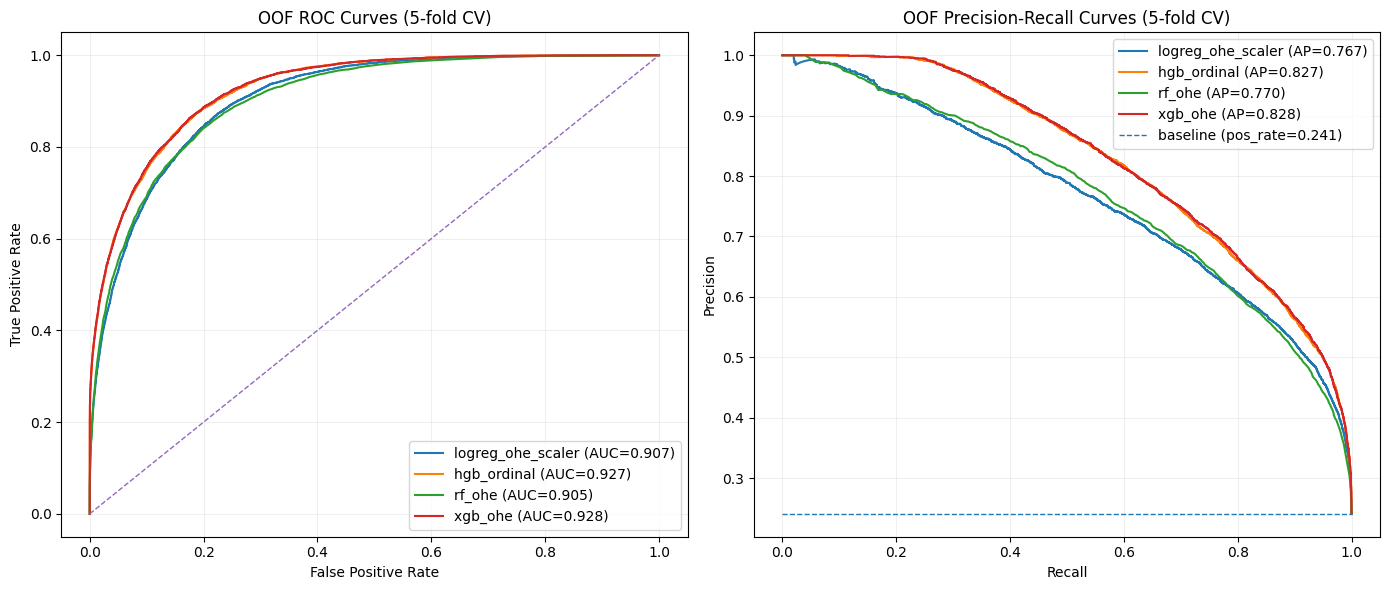

In [15]:
# OOF ROC + PR curves (4 models) — side-by-side comparison + save to reports/
# ------------------------------------------------------------------------------
# Assumes:
# - REPORTS_DIR exists (repo/reports)
# - target_enc (0/1 labels aligned with `data`)
# - oof_proba_logreg, oof_proba_hgb, oof_proba_rf, oof_proba_xgb

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    roc_auc_score,
    average_precision_score,
)

# --- Collect OOF probabilities (positive class) ---
oof_probas = {
    "logreg_ohe_scaler": oof_proba_logreg,
    "hgb_ordinal": oof_proba_hgb,
    "rf_ohe": oof_proba_rf,
    "xgb_ohe": oof_proba_xgb,
}

y_true = np.asarray(target_enc).astype(int)

# --- Output path (reports/) ---
plots_dir = Path(REPORTS_DIR) / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)
fig_path = plots_dir / "oof_roc_pr_curves_4_models.png"

# --- Create side-by-side plots ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# =========================
# ROC CURVES (left)
# =========================
ax = axes[0]
for name, proba in oof_probas.items():
    proba = np.asarray(proba)
    fpr, tpr, _ = roc_curve(y_true, proba)
    auc = roc_auc_score(y_true, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("OOF ROC Curves (5-fold CV)")
ax.grid(True, alpha=0.2)
ax.legend()

# =========================
# PR CURVES (right)
# =========================
ax = axes[1]
for name, proba in oof_probas.items():
    proba = np.asarray(proba)
    precision, recall, _ = precision_recall_curve(y_true, proba)
    ap = average_precision_score(y_true, proba)
    ax.plot(recall, precision, label=f"{name} (AP={ap:.3f})")

# Baseline precision = positive rate
pos_rate = float(y_true.mean())
ax.hlines(
    pos_rate, 0, 1,
    linestyles="--", linewidth=1,
    label=f"baseline (pos_rate={pos_rate:.3f})"
)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("OOF Precision-Recall Curves (5-fold CV)")
ax.grid(True, alpha=0.2)
ax.legend()

plt.tight_layout()

# ✅ Save in reports/
fig.savefig(fig_path, dpi=200, bbox_inches="tight")
print("Saved figure to:", fig_path)

plt.show()

## Collect CV means + select the best model key

In [16]:
# Collect CV means (choose the best model on PR-AUC)
cv_means = {
    "logreg_ohe_scaler": mean_logreg,  # must be the CV PR-AUC mean
    "hgb_ordinal": mean_hgb,            # must be the CV PR-AUC mean
    "rf_ohe": mean_rf,                  # must be the CV PR-AUC mean
    "xgb_ohe": mean_xgb,                # must be the CV PR-AUC mean
}

best_key = max(cv_means, key=cv_means.get)

print("Best model (by PR-AUC):", best_key, "| score =", round(cv_means[best_key], 4))
print("All PR-AUC CV means:", {k: round(v, 4) for k, v in cv_means.items()})

Best model (by PR-AUC): xgb_ohe | score = 0.8281
All PR-AUC CV means: {'logreg_ohe_scaler': 0.7672, 'hgb_ordinal': 0.826, 'rf_ohe': 0.7705, 'xgb_ohe': 0.8281}


## Map keys to model objects + pick the champion model

In [17]:
models = {
    "logreg_ohe_scaler": logreg_ohe_scaler,
    "hgb_ordinal": hgb_ordinal,
    "rf_ohe": rf_ohe,
    "xgb_ohe": xgb_ohe,
}

best_model = models[best_key]
best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('xgbclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehotencoder', ...), ('standardscaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the outpu

## Champion run (refit + test + log_model)

In [18]:
# Champion run — BEST PRACTICES (clean UI params + full params artifact) [reports/]
# ------------------------------------------------------------------------------
# Best practice:
# - Keep MLflow "Params" readable (only a small, meaningful subset)
# - Log full pipeline params as a JSON artifact for reproducibility (saved in repo/reports/)
# - Log imbalanced-friendly metrics (ROC-AUC, PR-AUC, F1, Recall)
# - Log the model artifact

import json
from pathlib import Path
import mlflow
import mlflow.sklearn

from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, recall_score

# Safety: close any active run (prevents "Run already active" errors)
mlflow.end_run()

with mlflow.start_run(run_name=f"{best_key}_champion"):
    # 1) Refit on train split
    best_model.fit(data_train, target_train)

    # 2) Predict labels + probabilities on test split
    y_pred = best_model.predict(data_test)
    y_proba = best_model.predict_proba(data_test)[:, 1]

    # 3) Final test metrics (imbalanced-friendly)
    test_roc_auc = roc_auc_score(target_test, y_proba)
    test_pr_auc = average_precision_score(target_test, y_proba)
    test_f1 = f1_score(target_test, y_pred)
    test_recall = recall_score(target_test, y_pred)

    # 4) Minimal, meaningful params in MLflow UI (human-readable)
    mlflow.log_param("selected_model", best_key)
    mlflow.log_param("selection_metric", "cv_pr_auc_mean")
    mlflow.log_param("cv_folds", 5)

    # Pipeline summary (from objects you already built)
    mlflow.log_param("categorical_encoder", categorical_preprocessor.__class__.__name__)
    mlflow.log_param("numerical_scaler", numerical_preprocessor.__class__.__name__)

    # Model family (last step of pipeline)
    try:
        mlflow.log_param("model_family", best_model.steps[-1][1].__class__.__name__)
    except Exception:
        mlflow.log_param("model_family", best_model.__class__.__name__)

    # 5) Metrics
    mlflow.log_metric("test_roc_auc", float(test_roc_auc))
    mlflow.log_metric("test_pr_auc", float(test_pr_auc))
    mlflow.log_metric("test_f1", float(test_f1))
    mlflow.log_metric("test_recall", float(test_recall))

    # 6) Full pipeline params as JSON artifact (saved in repo/reports/)
    reports_dir = Path(REPORTS_DIR)
    reports_dir.mkdir(parents=True, exist_ok=True)

    full_params = best_model.get_params(deep=True)
    params_path = reports_dir / f"champion_params_full_{best_key}.json"

    with open(params_path, "w", encoding="utf-8") as f:
        json.dump(full_params, f, indent=2, default=str)

    mlflow.log_artifact(str(params_path))

    # 7) Log the model artifact (candidate for Registry)
    mlflow.sklearn.log_model(best_model, name="model")

    print("Champion:", best_key)
    print(f"Test ROC-AUC : {test_roc_auc:.4f}")
    print(f"Test PR-AUC  : {test_pr_auc:.4f}")
    print(f"Test F1      : {test_f1:.4f}")
    print(f"Test Recall  : {test_recall:.4f}")
    print("Saved params to:", params_path)

Champion: xgb_ohe
Test ROC-AUC : 0.9220
Test PR-AUC  : 0.8189
Test F1      : 0.7011
Test Recall  : 0.6454
Saved params to: h:\Documents\2. Perso\github\mlflow\reports\champion_params_full_xgb_ohe.json


## ✅ Register the Champion Model in MLflow Model Registry

In [19]:
# Register the already-logged champion model (NO refit)
# ------------------------------------------------------------------------------
# This cell:
# - finds the most recent "{best_key}_champion" run in your experiment
# - registers its logged artifact "model" to the MLflow Model Registry
# - does NOT refit the pipeline (keeps test split untouched)

import mlflow
from mlflow.tracking import MlflowClient

# Safety: close any active run (prevents "Run already active" errors)
mlflow.end_run()

REGISTERED_MODEL_NAME = "adult_census_classifier"
EXPERIMENT_NAME = "adult_census_tracking"

# 1) Locate the latest champion run
exp = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
if exp is None:
    raise ValueError(f"Experiment not found: {EXPERIMENT_NAME}")

runs = mlflow.search_runs(
    experiment_ids=[exp.experiment_id],
    filter_string=f"tags.mlflow.runName = '{best_key}_champion'",
    order_by=["start_time DESC"],
    max_results=1,
)

if runs.empty:
    raise ValueError(f"No champion run found with run_name='{best_key}_champion'")

champion_run_id = runs.loc[0, "run_id"]
model_uri = f"runs:/{champion_run_id}/model"

# 2) Register the model artifact (creates a new Model Version)
result = mlflow.register_model(model_uri=model_uri, name=REGISTERED_MODEL_NAME)

print("Champion run_id:", champion_run_id)
print("Registered:", REGISTERED_MODEL_NAME, "| version:", result.version)

2026/01/21 15:48:35 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/01/21 15:48:35 INFO mlflow.store.db.utils: Updating database tables
2026/01/21 15:48:35 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/01/21 15:48:35 INFO alembic.runtime.migration: Will assume non-transactional DDL.
Registered model 'adult_census_classifier' already exists. Creating a new version of this model...
2026/01/21 15:48:36 WARNING mlflow.tracking._model_registry.fluent: Run with id df057ddc18e9470391a6a7d24710adb7 has no artifacts at artifact path 'model', registering model based on models:/m-1156fb59104a45b7bf4a4003ce7f64e2 instead
Created version '8' of model 'adult_census_classifier'.


Champion run_id: df057ddc18e9470391a6a7d24710adb7
Registered: adult_census_classifier | version: 8
